# Reinforcement Learning cơ bản: từ khái niệm đến DQN

Notebook này trả lời 5 câu hỏi nền tảng về **Reinforcement Learning (RL)** bằng ngôn ngữ dành cho người mới.

## Mục tiêu học tập

Sau notebook, bạn có thể:

- phân biệt `state`, `action`, `reward`, `return` và `policy`;
- hiểu $Q(s,a)$ và trực giác của phương trình Bellman;
- giải thích vai trò của discount factor $\gamma$;
- mô tả exploration, exploitation và chính sách $\varepsilon$-greedy;
- hiểu DQN dùng neural network, experience replay và target network để học ổn định hơn.

> **Bức tranh lớn:** Agent quan sát môi trường, chọn hành động, nhận phản hồi, rồi điều chỉnh cách ra quyết định để tối đa hóa tổng phần thưởng về lâu dài.

## 0. Vòng lặp tương tác trong RL

Ở thời điểm $t$:

1. Agent quan sát **state** $S_t$.
2. Agent dùng **policy** $\pi$ để chọn **action** $A_t$.
3. Môi trường chuyển sang state mới $S_{t+1}$ và trả về **reward** $R_{t+1}$.
4. Agent dùng trải nghiệm $(S_t,A_t,R_{t+1},S_{t+1})$ để học.

```text
              action A_t
       Agent -------------> Môi trường
         ^                     |
         | state S_{t+1},      |
         | reward R_{t+1}      |
         +---------------------+
```

Ví dụ xuyên suốt: một robot đi trong mê cung. Robot cần tìm đường tới đích, tránh chướng ngại và cố gắng đi ít bước.

## 1. State, action, reward, return và policy

| Khái niệm | Ký hiệu thường gặp | Câu hỏi nó trả lời | Ví dụ robot mê cung | Vai trò khi học |
|---|---:|---|---|---|
| **State** | $S_t=s$ | “Hiện tại tình huống là gì?” | Vị trí robot, vị trí đích, vật cản | Thông tin đầu vào để agent quyết định |
| **Action** | $A_t=a$ | “Agent có thể làm gì?” | Đi trái, phải, lên, xuống | Lựa chọn làm thay đổi môi trường |
| **Reward** | $R_{t+1}$ | “Hành động vừa rồi tốt đến đâu ngay lúc này?” | `+10` khi tới đích, `-1` mỗi bước | Tín hiệu phản hồi tức thời từ môi trường |
| **Return** | $G_t$ | “Tổng lợi ích từ bây giờ về sau là bao nhiêu?” | Tổng reward của các bước còn lại, có giảm giá | Mục tiêu dài hạn agent muốn tối đa hóa |
| **Policy** | $\pi(a\mid s)$ | “Ở state này nên chọn action nào?” | Xác suất chọn mỗi hướng đi | Chiến lược ra quyết định mà agent học được |

Return có chiết khấu được định nghĩa là:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots
$$

Trong đó $0 \le \gamma \le 1$ là **discount factor**.

### Reward khác return như thế nào?

- **Reward** là một phản hồi tại **một bước**.
- **Return** cộng các reward từ hiện tại đến tương lai, nên phản ánh hậu quả dài hạn.

Ví dụ, robot có hai lựa chọn:

- Nhặt đồng xu gần đó: nhận `+2` ngay, sau đó bị kẹt.
- Đi vòng: nhận `0` ngay, nhưng sau đó tới đích và nhận `+10`.

Nếu chỉ nhìn reward tức thời, robot dễ chọn đồng xu. Nếu tối đa hóa return, robot có thể học rằng đi vòng tốt hơn.

> **Ghi nhớ:** Reward do môi trường phát ra. Return được tính từ một chuỗi reward. Policy là cách agent chọn hành động để làm return kỳ vọng lớn nhất.

## 2. State-action value function $Q(s,a)$ và Bellman Equation

### $Q(s,a)$ biểu diễn điều gì?

$Q^\pi(s,a)$ là **return kỳ vọng** khi:

1. agent đang ở state $s$;
2. thực hiện action $a$;
3. từ bước sau tiếp tục hành động theo policy $\pi$.

$$
Q^\pi(s,a)=\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a]
$$

Nói đơn giản, $Q(s,a)$ là một **điểm đánh giá dài hạn** cho cặp `(state, action)`. Q-value lớn hơn nghĩa là hành động đó được kỳ vọng đem lại tổng phần thưởng tương lai tốt hơn.

Q-value **không nhất thiết bằng reward tức thời**. Một hành động có reward ngay lập tức thấp vẫn có thể có Q-value cao nếu nó dẫn đến state rất có lợi.

### Trực giác của Bellman Equation

Bellman Equation tách một bài toán dài hạn thành hai phần:

$$
\text{Giá trị hiện tại}
=
\text{reward ngay sau hành động}
+
\text{giá trị tốt nhất của tương lai đã chiết khấu}
$$

Với Q-value tối ưu:

$$
Q^*(s,a)
=
\mathbb{E}\left[R_{t+1}+\gamma\max_{a'}Q^*(S_{t+1},a')\mid S_t=s,A_t=a\right]
$$

Ý nghĩa từng phần:

- $R_{t+1}$: reward vừa nhận sau khi làm $a$;
- $S_{t+1}$: state kế tiếp;
- $\max_{a'}Q^*(S_{t+1},a')$: giá trị của lựa chọn tốt nhất ở state kế tiếp;
- $\gamma$: mức coi trọng tương lai;
- $\mathbb{E}$: lấy trung bình vì môi trường có thể ngẫu nhiên.

Đây là tính chất **đệ quy**: giá trị của hiện tại được viết qua giá trị của bước kế tiếp.

### Từ Bellman Equation đến quy tắc cập nhật Q-learning

Khi chưa biết $Q^*$, agent dùng trải nghiệm thực tế $(s,a,r,s')$ để tạo **TD target**:

$$
y = r + \gamma\max_{a'}Q(s',a')
$$

Sau đó dịch ước lượng cũ về phía target:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha\left[y-Q(s,a)\right]
$$

hay viết đầy đủ:

$$
Q(s,a) \leftarrow Q(s,a)+\alpha
\underbrace{\left[r+\gamma\max_{a'}Q(s',a')-Q(s,a)\right]}_{\text{TD error}}
$$

- $\alpha$ là learning rate: bước cập nhật lớn hay nhỏ.
- TD error cho biết dự đoán cũ lệch bao nhiêu so với mục tiêu mới.
- Nếu $s'$ là terminal state, phần tương lai bằng `0`, nên target chỉ còn $y=r$.

Bellman Equation là cơ sở của cập nhật vì nó cho agent một **mục tiêu học một bước** mà không cần đợi biết toàn bộ tương lai chính xác.

In [1]:
# Ví dụ số cho một lần cập nhật Q-learning
q_old = 2.0
reward = 1.0
gamma = 0.9
best_q_next = 5.0
alpha = 0.1

td_target = reward + gamma * best_q_next
td_error = td_target - q_old
q_new = q_old + alpha * td_error

print(f"Q cũ        = {q_old:.2f}")
print(f"TD target    = {reward} + {gamma} × {best_q_next} = {td_target:.2f}")
print(f"TD error     = {td_error:.2f}")
print(f"Q mới        = {q_new:.2f}")

Q cũ        = 2.00
TD target    = 1.0 + 0.9 × 5.0 = 5.50
TD error     = 3.50
Q mới        = 2.35


Kết quả trên cho thấy target là `5.5`, lớn hơn dự đoán cũ `2.0`. Với $\alpha=0.1$, agent không thay Q-value thành `5.5` ngay mà dịch chuyển một phần tới `2.35`. Cập nhật dần giúp giảm ảnh hưởng của một trải nghiệm ngẫu nhiên.

## 3. Discount factor $\gamma$ ảnh hưởng đến agent như thế nào?

$\gamma$ quyết định một reward trong tương lai còn có trọng số bao nhiêu ở hiện tại. Reward nhận sau $k$ bước được nhân với $\gamma^k$.

| Giá trị $\gamma$ | Hành vi thường thấy | Ưu điểm | Rủi ro |
|---|---|---|---|
| Gần `0` | “Thiển cận”, ưu tiên reward ngay | Học mục tiêu ngắn hạn nhanh | Bỏ qua lợi ích lớn đến muộn |
| Gần `1` | Nhìn xa, coi trọng reward tương lai | Lập kế hoạch dài hạn tốt hơn | Target dễ biến động, học có thể chậm hơn |

- Nếu $\gamma=0$, $G_t=R_{t+1}$: agent chỉ quan tâm reward kế tiếp.
- Nếu $\gamma$ gần `1`, reward xa vẫn có ảnh hưởng đáng kể.
- Với bài toán không kết thúc và reward không bị chặn thích hợp, đặt $\gamma=1$ có thể làm return không hữu hạn. Vì vậy thường dùng $\gamma<1$ cho continuing tasks.

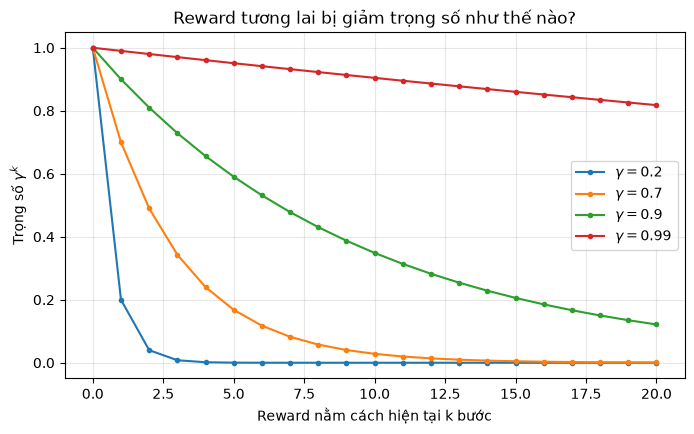

In [2]:
import numpy as np
import matplotlib.pyplot as plt

steps = np.arange(0, 21)
gammas = [0.2, 0.7, 0.9, 0.99]

plt.figure(figsize=(8, 4.5))
for gamma_value in gammas:
    plt.plot(steps, gamma_value**steps, marker="o", markersize=3,
             label=fr"$\gamma={gamma_value}$")

plt.xlabel("Reward nằm cách hiện tại k bước")
plt.ylabel(r"Trọng số $\gamma^k$")
plt.title("Reward tương lai bị giảm trọng số như thế nào?")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Ví dụ về sự đánh đổi ngắn hạn và dài hạn

Giả sử agent chọn giữa:

- **A:** nhận `4` ngay lập tức;
- **B:** nhận `10` sau 3 bước và không có reward trước đó.

Giá trị hiện tại của B là $\gamma^3\times 10$.

In [3]:
for gamma_value in [0.2, 0.5, 0.9, 0.99]:
    value_a = 4
    value_b = gamma_value**3 * 10
    choice = "A: 4 ngay" if value_a > value_b else "B: 10 sau 3 bước"
    print(f"gamma={gamma_value:>4}: A={value_a:.2f}, B={value_b:.2f} -> chọn {choice}")

gamma= 0.2: A=4.00, B=0.08 -> chọn A: 4 ngay
gamma= 0.5: A=4.00, B=1.25 -> chọn A: 4 ngay
gamma= 0.9: A=4.00, B=7.29 -> chọn B: 10 sau 3 bước
gamma=0.99: A=4.00, B=9.70 -> chọn B: 10 sau 3 bước


Không có một $\gamma$ tốt nhất cho mọi bài toán. Nó nên phản ánh **tầm thời gian** của nhiệm vụ: điều khiển phản xạ có thể dùng tầm nhìn ngắn hơn, còn lập kế hoạch đường đi cần nhìn xa hơn.

## 4. Exploration và exploitation

Agent đứng trước hai nhu cầu đối lập:

- **Exploitation (khai thác):** chọn action đang có Q-value cao nhất để tận dụng kiến thức đã học.
- **Exploration (khám phá):** thử action khác để thu thập thông tin mới.

Nếu chỉ exploitation từ đầu, agent có thể mắc kẹt với một hành động “tạm ổn” và không bao giờ phát hiện hành động tốt hơn. Nếu chỉ exploration, agent học được nhiều nhưng không tận dụng kiến thức để đạt reward cao.

Đây là **exploration–exploitation trade-off**.

### Cơ chế của $\varepsilon$-greedy policy

Ở mỗi lần chọn action:

- với xác suất $\varepsilon$: chọn một action ngẫu nhiên (**exploration**);
- với xác suất $1-\varepsilon$: chọn action có Q-value lớn nhất (**exploitation**).

$$
A_t=
\begin{cases}
\text{action ngẫu nhiên}, & \text{với xác suất }\varepsilon\\
\arg\max_a Q(S_t,a), & \text{với xác suất }1-\varepsilon
\end{cases}
$$

Nếu có nhiều action cùng đạt Q-value lớn nhất, nên phá hòa ngẫu nhiên để tránh ưu tiên cố định action có chỉ số đầu tiên.

In [4]:
rng = np.random.default_rng(seed=42)

def epsilon_greedy(q_values, epsilon, rng):
    # Chọn chỉ số action bằng epsilon-greedy, có phá hòa ngẫu nhiên.
    if rng.random() < epsilon:
        return int(rng.integers(len(q_values)))

    best_actions = np.flatnonzero(q_values == np.max(q_values))
    return int(rng.choice(best_actions))


q_values = np.array([1.0, 4.0, 2.0])  # Q(trái), Q(thẳng), Q(phải)
action_names = np.array(["trái", "thẳng", "phải"])

for epsilon in [0.0, 0.1, 0.8, 1.0]:
    counts = np.zeros(len(q_values), dtype=int)
    for _ in range(10_000):
        counts[epsilon_greedy(q_values, epsilon, rng)] += 1
    percentages = counts / counts.sum() * 100
    print(f"epsilon={epsilon:.1f}: " + ", ".join(
        f"{name}={pct:.1f}%" for name, pct in zip(action_names, percentages)
    ))

epsilon=0.0: trái=0.0%, thẳng=100.0%, phải=0.0%
epsilon=0.1: trái=2.9%, thẳng=93.5%, phải=3.5%


epsilon=0.8: trái=26.1%, thẳng=46.2%, phải=27.7%
epsilon=1.0: trái=33.1%, thẳng=32.9%, phải=34.0%


### Nếu $\varepsilon$ luôn quá lớn hoặc quá nhỏ

- **Luôn quá lớn:** agent hành động gần như ngẫu nhiên, nên hiệu suất thấp ngay cả khi đã biết action tốt.
- **Luôn quá nhỏ:** agent khám phá không đủ, dễ giữ lại đánh giá sai ban đầu hoặc kẹt ở policy chưa tối ưu.

Một cách phổ biến là **epsilon decay**:

1. đầu quá trình học dùng $\varepsilon$ lớn để khám phá;
2. giảm dần $\varepsilon$ để tăng khai thác;
3. thường giữ một $\varepsilon_{\min}>0$ nhỏ để vẫn còn cơ hội khám phá.

Ví dụ: $\varepsilon \leftarrow \max(\varepsilon_{\min},\lambda\varepsilon)$ với $0<\lambda<1$.

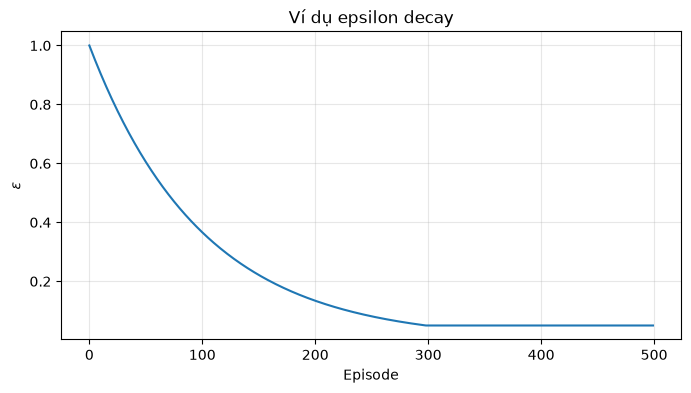

In [5]:
episodes = np.arange(500)
epsilon_start = 1.0
epsilon_min = 0.05
decay_rate = 0.99
epsilon_values = np.maximum(epsilon_min, epsilon_start * decay_rate**episodes)

plt.figure(figsize=(8, 4))
plt.plot(episodes, epsilon_values)
plt.xlabel("Episode")
plt.ylabel(r"$\varepsilon$")
plt.title("Ví dụ epsilon decay")
plt.grid(alpha=0.3)
plt.show()

## 5. Khi state space liên tục: Deep Q-Network (DQN)

### Vì sao Q-table không còn phù hợp?

Q-table cần một ô cho mọi cặp $(s,a)$. Với state liên tục, ví dụ vị trí $x=1.234...$, vận tốc $v=-0.057...$, có vô số giá trị state. Ta không thể lưu và ghé thăm đủ mọi ô.

DQN thay bảng bằng một neural network tham số $\theta$:

$$
Q(s,a;\theta) \approx Q^*(s,a)
$$

Với tập action rời rạc, network thường:

- nhận vector state làm input;
- xuất một Q-value cho mỗi action;
- chọn action greedy bằng $\arg\max_a Q(s,a;\theta)$.

Nhờ học một hàm, network có thể **khái quát hóa**: các state gần hoặc có đặc trưng giống nhau có thể nhận dự đoán tương tự, kể cả khi agent chưa gặp đúng state đó.

> **Giới hạn quan trọng:** DQN chuẩn xử lý state liên tục nhưng cần **action rời rạc**. Với action liên tục, thường dùng các họ thuật toán như DDPG, TD3 hoặc SAC.

In [6]:
import torch
from torch import nn

torch.manual_seed(42)

class QNetwork(nn.Module):
    # State liên tục -> một Q-value cho mỗi action rời rạc.
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, state):
        return self.net(state)


online_net = QNetwork(state_dim=4, n_actions=2)
sample_states = torch.tensor([
    [0.10, -0.20, 0.03, 0.50],
    [0.12, -0.18, 0.04, 0.47],
], dtype=torch.float32)

q_values = online_net(sample_states)
print("Shape input :", tuple(sample_states.shape), "= (batch_size, state_dim)")
print("Shape output:", tuple(q_values.shape), "= (batch_size, n_actions)")
print("Q-values dự đoán:\n", q_values.detach())

Shape input : (2, 4) = (batch_size, state_dim)
Shape output: (2, 2) = (batch_size, n_actions)
Q-values dự đoán:
 tensor([[-0.0175, -0.1516],
        [-0.0194, -0.1504]])


### Neural network học bằng cách nào?

Với một transition $(s,a,r,s',done)$, DQN tạo target theo Bellman:

$$
y =
\begin{cases}
r, & \text{nếu episode kết thúc}\\
r + \gamma\max_{a'}Q_{target}(s',a'), & \text{nếu chưa kết thúc}
\end{cases}
$$

Network online dự đoán $Q_{online}(s,a)$ và tối ưu loss, thường là MSE hoặc Huber loss:

$$
L(\theta)=\mathbb{E}\left[\left(y-Q_{online}(s,a;\theta)\right)^2\right]
$$

Backpropagation điều chỉnh trọng số $\theta$ để dự đoán tiến gần target.

### Experience replay và mini-batch

Nếu học ngay từ từng transition liên tiếp, các mẫu dữ liệu rất tương quan: nhiều frame liên tiếp gần như giống nhau. Hơn nữa, dữ liệu cũ nhanh chóng bị quên.

**Replay buffer** lưu các transition:

$$
(s,a,r,s',done)
$$

Khi cập nhật, agent lấy ngẫu nhiên một **mini-batch** từ buffer.

Lợi ích:

- phá bớt tương quan theo thời gian giữa các mẫu liên tiếp;
- tái sử dụng một trải nghiệm nhiều lần, tăng hiệu quả dữ liệu;
- mini-batch tạo gradient ít nhiễu hơn một mẫu đơn lẻ;
- trộn dữ liệu mới và cũ, giúp phân phối dữ liệu thay đổi chậm hơn.

Buffer không làm dữ liệu hoàn toàn độc lập, nhưng thường giúp việc học ổn định hơn đáng kể.

In [7]:
from collections import deque

replay_buffer = deque(maxlen=100_000)

# Một transition minh họa; trong bài toán thật, state là vector NumPy/tensor.
transition = (
    np.array([0.10, -0.20, 0.03, 0.50], dtype=np.float32),  # state
    1,                                                     # action
    1.0,                                                   # reward
    np.array([0.12, -0.18, 0.04, 0.47], dtype=np.float32),  # next_state
    False,                                                 # done
)
replay_buffer.append(transition)

print("Số transition đang lưu:", len(replay_buffer))
print("Các trường: state, action, reward, next_state, done")

Số transition đang lưu: 1
Các trường: state, action, reward, next_state, done


### Vì sao cần target network?

Nếu dùng cùng một network để vừa dự đoán $Q(s,a)$ vừa tạo target $r+\gamma\max Q(s',a')$, target sẽ thay đổi ngay mỗi lần network được cập nhật. Điều này giống như “đuổi theo một mục tiêu đang chạy”, dễ gây dao động hoặc phân kỳ.

DQN dùng hai network:

- **Online network** $Q_{online}$: được cập nhật bằng gradient ở mỗi bước học;
- **Target network** $Q_{target}$: tạo TD target và thay đổi chậm hơn.

Với **soft update**:

$$
\theta_{target}\leftarrow
\tau\theta_{online}+(1-\tau)\theta_{target}
$$

Trong đó $\tau$ nhỏ, ví dụ `0.005`. Target network chỉ dịch chuyển một phần nhỏ về phía online network, nên target ổn định hơn.

> Một biến thể khác là **hard update**: sao chép toàn bộ trọng số online sang target sau mỗi $C$ bước. Câu hỏi này tập trung vào soft update.

In [8]:
target_net = QNetwork(state_dim=4, n_actions=2)
target_net.load_state_dict(online_net.state_dict())

def soft_update(target_net, online_net, tau=0.005):
    # theta_target <- tau * theta_online + (1 - tau) * theta_target
    with torch.no_grad():
        for target_param, online_param in zip(
            target_net.parameters(), online_net.parameters()
        ):
            target_param.mul_(1.0 - tau)
            target_param.add_(online_param, alpha=tau)


soft_update(target_net, online_net, tau=0.005)
print("Đã soft-update target network.")

Đã soft-update target network.


### Ghép các thành phần trong một bước huấn luyện DQN

```text
Tương tác môi trường
        |
        v
Lưu (s, a, r, s', done) vào replay buffer
        |
        v
Lấy ngẫu nhiên một mini-batch
        |
        +--> online network: dự đoán Q(s, a)
        |
        +--> target network: tạo y = r + gamma * max Q_target(s', a')
        |
        v
Tính loss và cập nhật online network
        |
        v
Soft-update target network
```

Ba ý chính:

1. **Neural network** thay Q-table và khái quát hóa giữa các state.
2. **Experience replay + mini-batch** tái sử dụng và trộn dữ liệu để giảm tương quan.
3. **Target network** làm mục tiêu Bellman thay đổi chậm, giảm dao động.

In [9]:
import torch.nn.functional as F

def dqn_train_step(batch, online_net, target_net, optimizer, gamma=0.99):
    # Một bước cập nhật DQN tối giản cho action rời rạc.
    states, actions, rewards, next_states, dones = batch

    # Q_online(s, a): lấy đúng cột ứng với action đã thực hiện.
    predicted_q = online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # Target không tham gia backpropagation.
    with torch.no_grad():
        best_next_q = target_net(next_states).max(dim=1).values
        targets = rewards + gamma * (1.0 - dones) * best_next_q

    loss = F.smooth_l1_loss(predicted_q, targets)  # Huber loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()


# Kiểm tra hàm với một mini-batch giả lập, có seed để tái lập.
batch_size, state_dim, n_actions = 8, 4, 2
generator = torch.Generator().manual_seed(42)
batch = (
    torch.randn(batch_size, state_dim, generator=generator),
    torch.randint(n_actions, (batch_size,), generator=generator),
    torch.randn(batch_size, generator=generator),
    torch.randn(batch_size, state_dim, generator=generator),
    torch.randint(2, (batch_size,), generator=generator).float(),
)
optimizer = torch.optim.Adam(online_net.parameters(), lr=1e-3)
loss = dqn_train_step(batch, online_net, target_net, optimizer)
soft_update(target_net, online_net, tau=0.005)

print(f"Loss của mini-batch minh họa: {loss:.4f}")
print("Loss hữu hạn:", np.isfinite(loss))

Loss của mini-batch minh họa: 0.2729
Loss hữu hạn: True


## Tổng kết nhanh

| Câu hỏi | Ý cần nhớ |
|---|---|
| 1 | State là tình huống; action là lựa chọn; reward là phản hồi một bước; return là tổng reward tương lai; policy là chiến lược chọn action. |
| 2 | $Q(s,a)$ đánh giá lợi ích dài hạn của action $a$ tại state $s$. Bellman biến mục tiêu dài hạn thành reward hiện tại cộng giá trị tương lai. |
| 3 | $\gamma$ nhỏ ưu tiên trước mắt; $\gamma$ lớn coi trọng dài hạn. |
| 4 | Exploration tìm hiểu lựa chọn mới; exploitation tận dụng điều đã biết. $\varepsilon$-greedy trộn hai hành vi này. |
| 5 | DQN xấp xỉ Q bằng neural network; replay buffer giảm tương quan và tái sử dụng dữ liệu; target network làm target ổn định hơn. |

### Một câu để nối tất cả khái niệm

Agent quan sát **state**, dùng **policy** để chọn **action**, nhận **reward**, và học ước lượng **Q-value** theo mục tiêu Bellman để tối đa hóa **return**; $\gamma$ điều chỉnh tầm nhìn, $\varepsilon$-greedy cân bằng khám phá–khai thác, còn DQN mở rộng cách học này sang state space quá lớn hoặc liên tục.

## Câu hỏi tự kiểm tra

1. Vì sao reward `+5` ngay lập tức chưa đủ để kết luận một action tốt?
2. Trong Q-learning, target là gì nếu transition dẫn tới terminal state?
3. Nếu agent luôn chọn action có Q-value lớn nhất ngay từ đầu, rủi ro là gì?
4. Trong DQN, network nào nhận gradient trực tiếp: online hay target?
5. DQN chuẩn có trực tiếp xử lý action liên tục không?

<details>
<summary><b>Xem đáp án</b></summary>

1. Vì cần xét cả reward tương lai, tức return; action đó có thể gây hậu quả xấu về sau.
2. Target bằng chính reward: $y=r$.
3. Khám phá không đủ và có thể mắc kẹt ở policy chưa tối ưu.
4. Online network. Target network được cập nhật chậm từ online network.
5. Không. DQN chuẩn dành cho action rời rạc; action liên tục thường dùng DDPG, TD3 hoặc SAC.

</details>